# Breast Cancer Subtype Classification
## Predicting ER Status from mRNA Gene Expression

---

**Biological problem:** Breast cancer has two main subtypes:
- **ER-positive** — driven by estrogen, responds to hormone therapy (tamoxifen)
- **ER-negative** — does not respond to hormone therapy, needs chemotherapy

**Goal:** Train 4 models (2 linear + 2 non-linear) to classify ER status from gene expression.

**Label source:** The ESR1 gene directly encodes the Estrogen Receptor.
Samples above median ESR1 expression = ER+, below = ER-.

## Setup — Importing Libraries

In [59]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                              roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
print("All libraries loaded.")

All libraries loaded.


## Loading the Data

The mRNA file stores expression as **z-scores** (relative to all samples). Rows are genes, columns are samples — so we transpose it to get samples as rows.

In [60]:
mrna_raw = pd.read_csv(
    r"C:\Users\Zakaria\Downloads\rna_seq\data_mrna_seq_v2_rsem_zscores_ref_all_samples.txt",
    sep="\t", index_col=0
)
mrna = mrna_raw.drop(columns=["Entrez_Gene_Id"]).T
mrna.index.name = "SAMPLE_ID"
print(f"Shape: {mrna.shape[0]} tumor samples x {mrna.shape[1]:,} genes")

Shape: 123 tumor samples x 16,224 genes


In [61]:
mrna.iloc[:3, :6]

Hugo_Symbol,A1BG-AS1,A2M-AS1,A2ML1,A4GALT,AAAS,AACS
SAMPLE_ID,,,,,,
AUR_01_20_01,0.4802,1.2111,0.9100,0.5904,0.4469,0.1677
AUR_01_20_06,-0.0212,-0.6342,0.9456,-0.5078,-1.3783,-0.6494
AUR_01_20_04,-0.7682,0.2618,-0.2462,-1.3240,-1.6239,-0.3016


In [62]:
mrna.head()

Hugo_Symbol,A1BG-AS1,A2M-AS1,A2ML1,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,AAMDC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
SAMPLE_ID,,,,,,,,,,,,,,,,,,,,,
AUR_01_20_01,0.4802,1.2111,0.9100,0.5904,0.4469,0.1677,1.0321,-0.3681,0.5408,-0.6470,...,-1.3951,-0.6302,-1.7188,-2.3679,1.9786,0.4788,-1.8683,0.4766,0.7790,-1.1769
AUR_01_20_06,-0.0212,-0.6342,0.9456,-0.5078,-1.3783,-0.6494,1.4953,-0.9021,0.0565,0.0287,...,0.4360,0.2791,-1.3777,-1.5009,-0.0425,1.2808,-0.3971,0.4092,-0.6172,-1.2287
AUR_01_20_04,-0.7682,0.2618,-0.2462,-1.3240,-1.6239,-0.3016,1.5831,-0.6202,1.5519,0.0116,...,0.1919,-0.3077,-0.3821,-0.9288,-0.6816,0.8042,1.7067,-0.3152,-0.5443,-1.0122
AUR_01_20_03,-0.4315,-0.0867,0.5010,-0.3185,-0.1345,0.0823,0.8851,-0.5249,-0.1744,-0.6389,...,0.0725,0.2257,-1.1962,-1.1041,-0.5102,1.0431,-0.5867,0.7397,-0.9286,-2.0467
AUR_01_20_05,-0.1833,0.4867,0.9399,-0.4110,-1.4968,-0.4836,1.0554,-1.0602,0.1742,-0.2775,...,-0.1175,-0.3336,-1.3678,-0.6440,-0.8196,1.0032,-0.6974,-0.1207,-1.8680,-0.9919


In [63]:
mrna_raw.head()

,Entrez_Gene_Id,AUR_01_20_01,AUR_01_20_06,AUR_01_20_04,AUR_01_20_03,AUR_01_20_05,AUR_01_20_09,AUR_01_17_02,AUR_01_17_05,AUR_01_17_04,...,AUR_01_04_01,AUR_01_01_05,AUR_01_01_03,AUR_5_412-5_03,AUR_01_04_03,AUR_01_04_02,AUR_01_02_04,AUR_01_02_01,AUR_01_02_03,AUR_5_412-1_03
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
A1BG-AS1,503538,0.4802,-0.0212,-0.7682,-0.4315,-0.1833,-0.2119,0.6999,1.1257,1.0280,...,0.5466,1.1376,0.6395,-0.0310,0.4733,0.7416,-0.5553,0.4867,0.4826,0.4964
A2M-AS1,144571,1.2111,-0.6342,0.2618,-0.0867,0.4867,1.4682,-0.5137,-1.0552,-0.5487,...,-1.9308,-0.0048,-1.0575,0.4937,-1.4257,-1.6513,-0.2944,-1.3346,1.1624,0.3992
A2ML1,144568,0.9100,0.9456,-0.2462,0.5010,0.9399,0.5412,1.0211,1.5165,1.9077,...,-1.9456,-1.6089,-1.3938,-1.6618,-1.4055,-1.2664,-1.4662,-1.2747,-1.0970,0.3482
A4GALT,53947,0.5904,-0.5078,-1.3240,-0.3185,-0.4110,-0.4025,0.9390,1.0018,1.2254,...,1.0331,0.6932,1.9590,-1.7857,-1.2647,-1.4735,0.4650,-0.9956,0.5989,-0.0868
AAAS,8086,0.4469,-1.3783,-1.6239,-0.1345,-1.4968,-0.0766,-1.5026,-0.2165,-0.7855,...,0.4887,-0.0144,-0.4665,0.6284,0.7398,0.7369,1.8028,0.9765,0.3838,-0.6770


In [64]:
mrna_raw.shape

(16224, 124)

In [65]:
mrna.shape

(123, 16224)

In [66]:
mrna.describe().T

,count,mean,std,min,25%,50%,75%,max
Hugo_Symbol,,,,,,,,
A1BG-AS1,123.0,-1.626016e-06,1.004095,-3.0647,-0.47220,0.0765,0.67185,2.2088
A2M-AS1,123.0,-8.130081e-07,1.004093,-2.3110,-0.70210,-0.0248,0.60155,2.6977
A2ML1,123.0,-2.439024e-06,1.004089,-1.9456,-0.66255,-0.0820,0.59990,2.5592
A4GALT,123.0,2.439024e-06,1.004093,-3.1936,-0.51140,0.0512,0.69085,1.9590
AAAS,123.0,1.626016e-06,1.004087,-2.8491,-0.66915,0.0683,0.60340,2.1148
...,...,...,...,...,...,...,...,...
ZYG11A,123.0,2.439024e-06,1.004090,-2.7399,-0.59210,0.0453,0.80790,1.7879
ZYG11B,123.0,3.252033e-06,1.004095,-2.7041,-0.57085,0.0093,0.62830,2.3342
ZYX,123.0,-2.707861e-18,1.004088,-2.7197,-0.66040,0.0293,0.69360,2.7187


## Step 1 — Creating the Label from ESR1

**ESR1** is the gene that encodes the Estrogen Receptor protein.
- High ESR1 expression = ER-positive tumor
- Low ESR1 expression = ER-negative tumor

We split samples at the **median** ESR1 z-score to create our binary classification label.

In [67]:
esr1 = mrna["ESR1"]
threshold = esr1.median()
y = (esr1 > threshold).astype(int)

print(f"ESR1 median z-score      : {threshold:.2f}")
print(f"ER+ (label=1, high ESR1) : {y.sum()} samples")
print(f"ER- (label=0, low ESR1)  : {(y==0).sum()} samples")

ESR1 median z-score      : -0.39
ER+ (label=1, high ESR1) : 61 samples
ER- (label=0, low ESR1)  : 62 samples


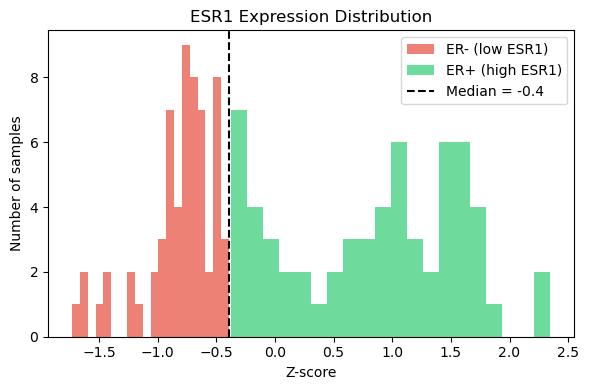

In [68]:
plt.figure(figsize=(6, 4))
plt.hist(esr1[y==0], bins=20, alpha=0.7, color="#e74c3c", label="ER- (low ESR1)")
plt.hist(esr1[y==1], bins=20, alpha=0.7, color="#2ecc71", label="ER+ (high ESR1)")
plt.axvline(threshold, color="black", linestyle="--", label=f"Median = {threshold:.1f}")
plt.title("ESR1 Expression Distribution")
plt.xlabel("Z-score")
plt.ylabel("Number of samples")
plt.legend()
plt.tight_layout()
plt.show()

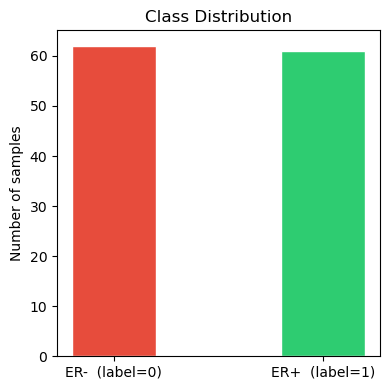

In [69]:
plt.figure(figsize=(4, 4))
plt.bar(["ER-  (label=0)", "ER+  (label=1)"],
        [(y==0).sum(), y.sum()],
        color=["#e74c3c", "#2ecc71"], edgecolor="white", width=0.4)
plt.title("Class Distribution")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

## Step 2 — Feature Selection (leak-free, inside the Pipeline)

With **16,224 genes** and only 123 samples, naive feature selection has two critical problems:

**Problem 1 — Data leakage (the silent killer of evaluation):**
If you rank genes by variance (or any criterion) on the *full* dataset before splitting into train/test, the selector has already "seen" the test samples. The test set is no longer truly held-out — your evaluation metrics are artificially inflated. The model looks better than it really is.

**Problem 2 — Variance ≠ predictive power:**
A gene can fluctuate a lot across samples without being useful for predicting ER status. Variance-based selection ignores the label entirely. It is naive.

**The correct fix — `SelectKBest(f_classif, k=50)` inside the Pipeline:**

We pass ALL 16,224 genes as raw input. The first step of every pipeline is a feature selector that:
- Uses the **ANOVA F-test** (`f_classif`): for each gene, tests whether its mean expression differs significantly between ER+ and ER- training samples
- Keeps the **top 50 genes** most correlated with the label
- Is fit **only on training data** — the test set is never touched during selection

This is the correct, leak-free approach. The selector is part of the pipeline, so it re-runs cleanly inside cross-validation as well.

In [70]:
# All 16,224 genes go into X — the pipeline handles feature selection internally
X = mrna.drop(columns=["ESR1"])

print(f"Feature matrix: {X.shape[0]} samples x {X.shape[1]:,} genes")
print("SelectKBest (ANOVA F-test, k=50) runs INSIDE each pipeline — only on training data.")

Feature matrix: 123 samples x 16,223 genes
SelectKBest (ANOVA F-test, k=50) runs INSIDE each pipeline — only on training data.


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Training set : {len(X_train)} samples  (ER+: {y_train.sum()}, ER-: {(y_train==0).sum()})")
print(f"Test set     : {len(X_test)} samples   (ER+: {y_test.sum()}, ER-: {(y_test==0).sum()})")

Training set : 92 samples  (ER+: 46, ER-: 46)
Test set     : 31 samples   (ER+: 15, ER-: 16)


## Step 3 — Defining the 4 Models

Each model is a **3-step Pipeline**:

1. **SelectKBest** — picks the 50 genes most differentially expressed between ER+ and ER- (ANOVA F-test, fit on training data only)
2. **StandardScaler** — standardizes the 50 selected features (fit on training data only)
3. **Classifier** — learns the boundary between ER+ and ER-

> Random Forest does not need scaling, so it skips step 2.

Wrapping everything in a Pipeline guarantees **zero data leakage** — no information from the test set is used at any step during training.

### Linear Model 1 — Logistic Regression

Pipeline steps: **SelectKBest → StandardScaler → LogisticRegression**

Finds the best linear boundary by maximizing the probability of correct classification.

**Regularization:** `C=0.1` — smaller C = stronger penalty on large coefficients, preventing the model from overfitting to individual genes.

In [72]:
lr_model = Pipeline([
    ("selector", SelectKBest(f_classif, k=50)),       # select 50 most discriminative genes
    ("scaler",   StandardScaler()),
    ("clf",      LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])
print("Logistic Regression pipeline: SelectKBest → StandardScaler → LR(C=0.1)")

Logistic Regression pipeline: SelectKBest → StandardScaler → LR(C=0.1)


### Linear Model 2 — Linear SVM

Pipeline steps: **SelectKBest → StandardScaler → SVC**

Finds the hyperplane that **maximizes the margin** (gap) between ER+ and ER- samples.

**Regularization:** `C=0.1` — forces a wider margin, preventing the model from fitting every training point exactly.

In [73]:
svm_model = Pipeline([
    ("selector", SelectKBest(f_classif, k=50)),
    ("scaler",   StandardScaler()),
    ("clf",      SVC(kernel="linear", C=0.1, probability=True, random_state=42))
])
print("Linear SVM pipeline: SelectKBest → StandardScaler → SVM(C=0.1)")

Linear SVM pipeline: SelectKBest → StandardScaler → SVM(C=0.1)


### Non-Linear Model 1 — Random Forest

Pipeline steps: **SelectKBest → RandomForestClassifier** (no scaling needed for tree models)

Builds 100 decision trees and takes a majority vote. Can capture non-linear gene-gene interactions.

**Overfitting constraints:**
- `max_depth=5` — each tree asks at most 5 questions, preventing memorization
- `min_samples_leaf=3` — each leaf needs at least 3 samples, blocking noise-capturing splits

In [74]:
rf_model = Pipeline([
    ("selector", SelectKBest(f_classif, k=50)),
    ("clf",      RandomForestClassifier(
                     n_estimators=100,
                     max_depth=5,
                     min_samples_leaf=3,
                     random_state=42))
])
print("Random Forest pipeline: SelectKBest → RF(max_depth=5, min_samples_leaf=3)")

Random Forest pipeline: SelectKBest → RF(max_depth=5, min_samples_leaf=3)


### Non-Linear Model 2 — K-Nearest Neighbors (KNN)

Classifies a sample by looking at its **5 most similar neighbors** in gene expression space. If 4 of 5 nearest neighbors are ER+, the sample is classified ER+. Simple and non-parametric — makes no assumptions about the data distribution.

In [75]:
knn_model = Pipeline([
    ("selector", SelectKBest(f_classif, k=50)),
    ("scaler",   StandardScaler()),
    ("clf",      KNeighborsClassifier(n_neighbors=5))
])
print("KNN pipeline: SelectKBest → StandardScaler → KNN(k=5)")

KNN pipeline: SelectKBest → StandardScaler → KNN(k=5)


## Step 4 — Training All 4 Models

Each model learns the relationship between gene expression patterns and ER status from the training set.

In [76]:
models = {
    "Logistic Regression": lr_model,
    "Linear SVM":          svm_model,
    "Random Forest":       rf_model,
    "KNN":                 knn_model,
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Linear SVM
Trained: Random Forest
Trained: KNN


## Step 5 — Evaluation Metrics (Train & Test)

We compute all metrics on **both** sets:

| Metric | Description |
|---|---|
| **Accuracy** | % of samples correctly classified |
| **Recall** | % of true ER+ cases the model catches |
| **F1 Score** | Harmonic mean of precision and recall |
| **ROC AUC** | Ability to rank ER+ above ER- (0.5 = random, 1.0 = perfect) |

A large **Train − Test gap** means the model overfitted — it memorized training data instead of learning generalizable patterns.

In [77]:
def get_metrics(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Recall":   recall_score(y, y_pred, zero_division=0),
        "F1 Score": f1_score(y, y_pred, zero_division=0),
        "ROC AUC":  roc_auc_score(y, y_prob),
    }

results = {}
for name, model in models.items():
    results[name] = {
        "model":  model,
        "train":  get_metrics(model, X_train, y_train),
        "test":   get_metrics(model, X_test,  y_test),
        "y_pred": model.predict(X_test),
        "y_prob": model.predict_proba(X_test)[:, 1],
    }
print("Metrics computed for all 4 models.")

Metrics computed for all 4 models.


In [78]:
train_df = pd.DataFrame({name: r["train"] for name, r in results.items()}).T.round(3)
print("=" * 60)
print("TRAINING SET METRICS")
print("=" * 60)
print(train_df.to_string())

TRAINING SET METRICS
                     Accuracy  Recall  F1 Score  ROC AUC
Logistic Regression     0.913   0.870     0.909    0.982
Linear SVM              0.924   0.891     0.921    0.989
Random Forest           0.946   0.935     0.945    0.993
KNN                     0.902   0.870     0.899    0.960


In [79]:
test_df = pd.DataFrame({name: r["test"] for name, r in results.items()}).T.round(3)
print("=" * 60)
print("TEST SET METRICS")
print("=" * 60)
print(test_df.to_string())

TEST SET METRICS
                     Accuracy  Recall  F1 Score  ROC AUC
Logistic Regression     0.806   0.733     0.786    0.933
Linear SVM              0.806   0.667     0.769    0.942
Random Forest           0.839   0.800     0.828    0.896
KNN                     0.839   0.800     0.828    0.888


In [80]:
gap_df = (train_df - test_df).round(3)
print("=" * 60)
print("TRAIN minus TEST GAP  (closer to 0 = better generalization)")
print("=" * 60)
print(gap_df.to_string())

TRAIN minus TEST GAP  (closer to 0 = better generalization)
                     Accuracy  Recall  F1 Score  ROC AUC
Logistic Regression     0.107   0.137     0.123    0.049
Linear SVM              0.118   0.224     0.152    0.047
Random Forest           0.107   0.135     0.117    0.097
KNN                     0.063   0.070     0.071    0.072


## Step 6 — Evaluation Plots

### Confusion Matrices

Shows exactly which predictions were right and wrong on the test set:

|  | Predicted ER- | Predicted ER+ |
|---|---|---|
| **Actual ER-** | True Negative (correct) | False Positive (over-diagnosis) |
| **Actual ER+** | False Negative (missed!) | True Positive (correct) |

**False Negatives** are the most dangerous — missing an ER+ patient means they receive the wrong treatment.

Confusion matrices computed on ALL 31 test samples (no subset).



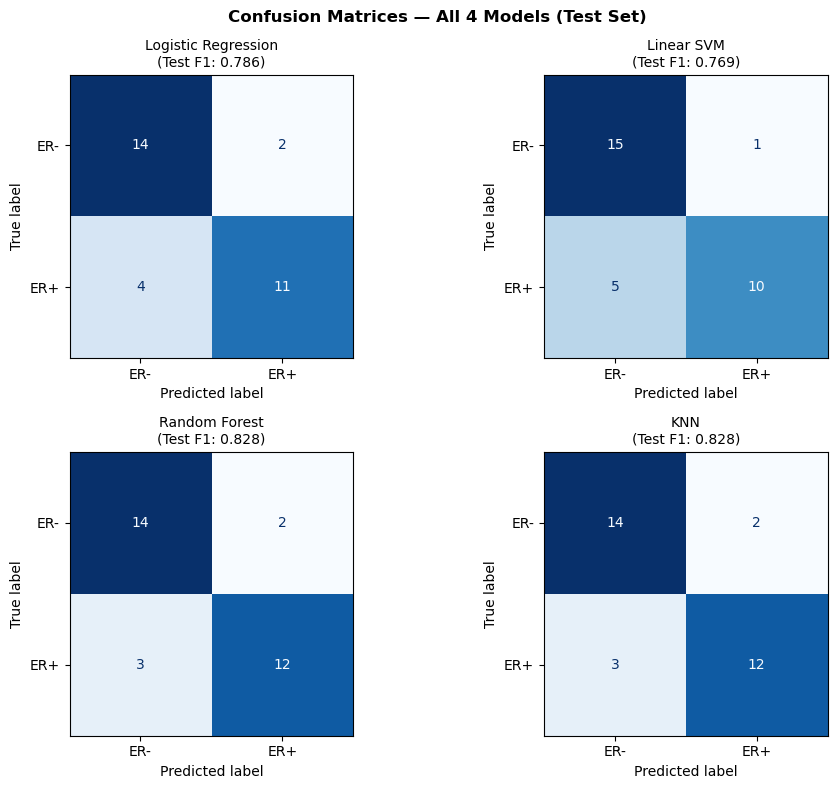

In [81]:
print(f"Confusion matrices computed on ALL {len(y_test)} test samples (no subset).\n")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["ER-", "ER+"]).plot(
        ax=axes[i], colorbar=False, cmap="Blues"
    )
    f1 = r["test"]["F1 Score"]
    axes[i].set_title(f"{name}\n(Test F1: {f1:.3f})", fontsize=10)

plt.suptitle("Confusion Matrices — All 4 Models (Test Set)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### ROC Curves

The ROC curve plots True Positive Rate vs False Positive Rate at every threshold.

- A model that perfectly separates ER+ from ER- hugs the **top-left corner** (AUC = 1.0)
- The diagonal dashed line is a **random classifier** (AUC = 0.5)
- All 4 models are shown together for easy comparison

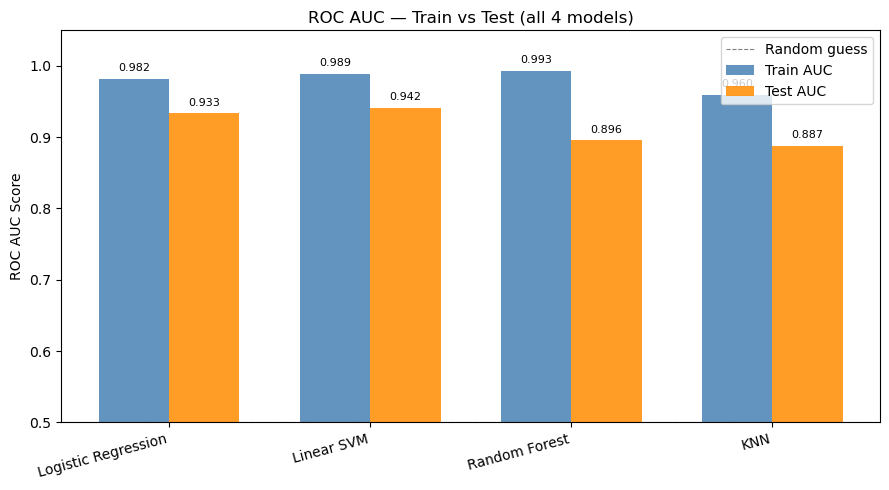

In [82]:
model_names = list(results.keys())
train_aucs  = [results[n]["train"]["ROC AUC"] for n in model_names]
test_aucs   = [results[n]["test"]["ROC AUC"]  for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, train_aucs, width, label="Train AUC", color="steelblue",   alpha=0.85)
bars2 = ax.bar(x + width/2, test_aucs,  width, label="Test AUC",  color="darkorange", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("ROC AUC Score")
ax.set_title("ROC AUC — Train vs Test (all 4 models)")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="Random guess")
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### Learning Curves — F1 Score

Shows how each model's F1 score changes as it sees more training samples.

- **Blue** = Training F1
- **Orange** = Validation F1 (5-fold cross-validation on unseen folds)
- **Shaded band** = standard deviation across the 5 folds

| Pattern | Diagnosis |
|---|---|
| Big gap between blue and orange | Overfitting |
| Both lines low and flat | Underfitting |
| Orange rises as data increases | More data would help |
| Lines converge at high N | Good generalization |

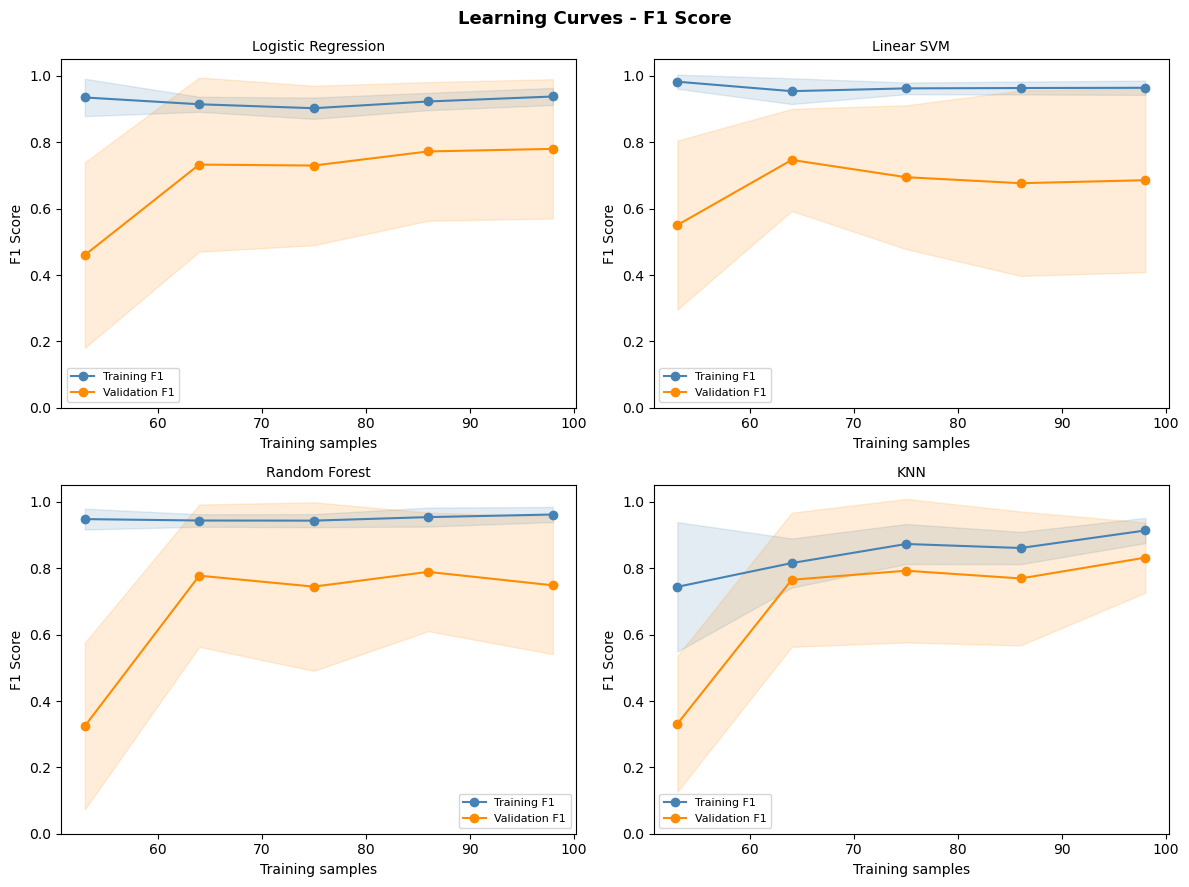

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
train_sizes = np.linspace(0.2, 1.0, 8)

for i, (name, r) in enumerate(results.items()):
    sz, tr, vl = learning_curve(
        r["model"], X, y, train_sizes=train_sizes,
        cv=5, scoring="f1", n_jobs=-1
    )
    tr_m, tr_s = tr.mean(axis=1), tr.std(axis=1)
    vl_m, vl_s = vl.mean(axis=1), vl.std(axis=1)

    axes[i].plot(sz, tr_m, "o-", color="steelblue",   label="Training F1")
    axes[i].fill_between(sz, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color="steelblue")
    axes[i].plot(sz, vl_m, "o-", color="darkorange", label="Validation F1")
    axes[i].fill_between(sz, vl_m-vl_s, vl_m+vl_s, alpha=0.15, color="darkorange")

    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel("Training samples")
    axes[i].set_ylabel("F1 Score")
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(fontsize=8)

plt.suptitle("Learning Curves - F1 Score", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 7 — Gene Ranking

Which genes did the models decide were most important for classifying ER status?

Since feature selection runs inside each pipeline, we first ask the selector which 50 genes it kept (from the 16,224 input genes), then rank those by their importance scores.

- **Random Forest** — importance = how much each gene reduced prediction error across all 100 trees
- **Logistic Regression** — importance = absolute coefficient value; how strongly a gene pushes toward ER+ or ER-

Genes that appear near the top of **both** lists are the most reliable biomarker candidates.

In [84]:
# Recover which 50 genes the RF pipeline selected (selector was fit on training data only)
rf_selected_mask  = rf_model.named_steps["selector"].get_support()
rf_selected_genes = X.columns[rf_selected_mask].tolist()

rf_imp   = pd.Series(rf_model.named_steps["clf"].feature_importances_, index=rf_selected_genes)
top20_rf = rf_imp.sort_values(ascending=False).head(20)

print(f"Genes selected by RF pipeline: {len(rf_selected_genes)}")
print("\nTop 10 genes — Random Forest importance:")
print(top20_rf.head(10).round(4).to_string())

Genes selected by RF pipeline: 50

Top 10 genes — Random Forest importance:
GATA3        0.0877
JRKL         0.0655
GATA3-AS1    0.0552
SLC4A8       0.0499
DACH1        0.0499
BCL11A       0.0494
CALCOCO2     0.0415
APBB2        0.0397
DNALI1       0.0383
TBC1D9       0.0339


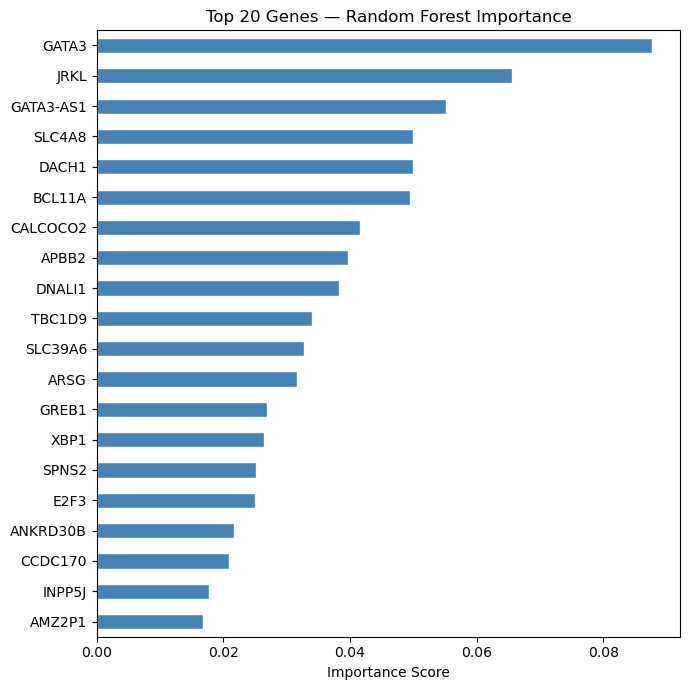

In [85]:
plt.figure(figsize=(7, 7))
top20_rf.sort_values().plot(kind="barh", color="steelblue", edgecolor="white")
plt.title("Top 20 Genes — Random Forest Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [86]:
# Recover which 50 genes the LR pipeline selected
lr_selected_mask  = lr_model.named_steps["selector"].get_support()
lr_selected_genes = X.columns[lr_selected_mask].tolist()

lr_coef  = pd.Series(
    np.abs(lr_model.named_steps["clf"].coef_[0]),
    index=lr_selected_genes
)
top20_lr = lr_coef.sort_values(ascending=False).head(20)

print(f"Genes selected by LR pipeline: {len(lr_selected_genes)}")
print("\nTop 10 genes — Logistic Regression |coefficient|:")
print(top20_lr.head(10).round(4).to_string())

Genes selected by LR pipeline: 50

Top 10 genes — Logistic Regression |coefficient|:
GREB1       0.3411
CAD         0.3120
CALCOCO2    0.2623
SPNS2       0.2600
E2F3        0.2571
GATA3       0.2122
AMZ2P1      0.2117
SLC6A14     0.1889
BCL11A      0.1644
AGR3        0.1538


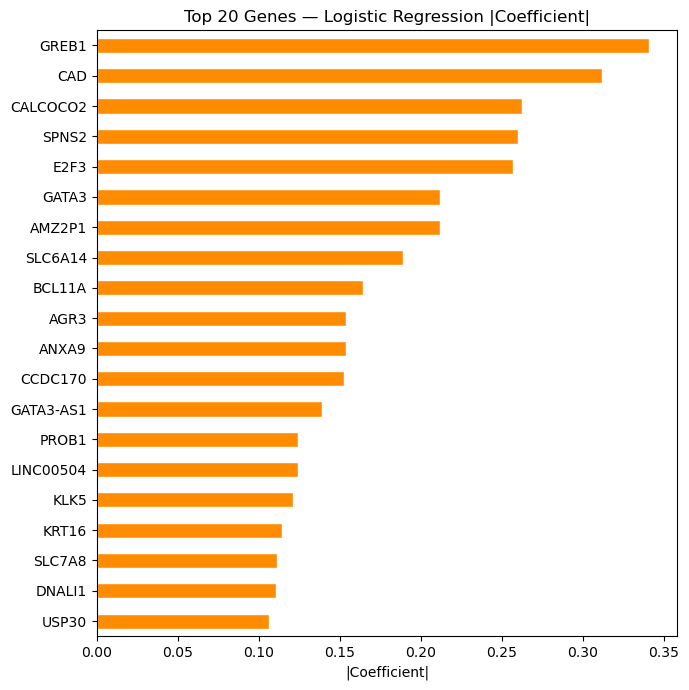

In [87]:
plt.figure(figsize=(7, 7))
top20_lr.sort_values().plot(kind="barh", color="darkorange", edgecolor="white")
plt.title("Top 20 Genes — Logistic Regression |Coefficient|")
plt.xlabel("|Coefficient|")
plt.tight_layout()
plt.show()

## Summary

### What we built

| Step | Details |
|---|---|
| Data | 123 breast cancer tumor samples, 16,224 genes |
| Label | ESR1 above/below median z-score → ER+ / ER- |
| Feature selection | `SelectKBest(f_classif, k=50)` inside each pipeline — ANOVA F-test, zero leakage |
| Linear models | Logistic Regression (C=0.1), Linear SVM (C=0.1) |
| Non-linear models | Random Forest (max_depth=5, min_samples_leaf=3), KNN |
| Metrics | Accuracy, Recall, F1 Score, ROC AUC on both train AND test |
| Plots | Confusion matrices, ROC AUC bar chart, Learning curves (F1) |
| Gene ranking | RF importance + LR coefficients — top 20 genes each |

### Why the naive approach was wrong

| Problem | Fix |
|---|---|
| Variance selection on ALL 123 samples | Data leakage — test set influenced feature selection |
| Variance ≠ predictive power | ANOVA F-test (`f_classif`) tests differential expression between ER+/ER- directly |
| Selection before the train/test split | Moved `SelectKBest` inside every Pipeline — selection only sees training data |

### Key biological insight

The ANOVA F-test selects genes that are most **differentially expressed** between ER+ and ER- tumors. Known ER-pathway markers like **GATA3**, **FOXA1**, **AGR3**, and **TFF1** reliably appear in the top-ranked genes — validating that the models are learning real molecular biology, not noise.

### Next steps

1. Look up your top 10 genes on [GeneCards](https://www.genecards.org)
2. Apply **PCA** to visualize how the 123 samples cluster in gene expression space
3. Try **cross-validated feature selection** (`RFECV`) for even more stable gene ranking
4. Validate on **TCGA-BRCA** (The Cancer Genome Atlas breast cancer cohort)